# Clean up FNO pipeline

This is for the 2D Darcy problem on [0, 1]^2, with input permeability field discrete in {0, 1}.

In [192]:
# Imports
import numpy as np
import sys

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern

import torch
from torch.utils.data import DataLoader

import neuralop
from neuralop.models import FNO
from neuralop import Trainer, LpLoss, H1Loss
from neuralop.training import AdamW
from neuralop.data.datasets import load_darcy_flow_small, DarcyDataset
from neuralop.utils import count_model_params

import matplotlib.pyplot as plt


In [193]:
# ===== HYPERPARAMETERS =====

# === Data ===
data_n_train = 1_000
data_n_tests = [100, 50]
data_train_resolution = 64  # options: 16, 32, 64, 128, 421
data_test_resolutions = [64, 128]
data_batch_size = 32
data_test_batch_sizes = [32, 32]

# === Model ===
FNO_n_modes=(25, 25)
FNO_in_channels=1
FNO_out_channels=1
FNO_hidden_channels=32  # Width of model. Documentation recommends 64, but 32 is sufficient for our purposes and much faster to train.
FNO_n_layers = 4  # Number of Fourier layers.
FNO_projection_channel_ratio=2
FNO_factorization="tucker"
FNO_rank=0.42

# === Training ===
TRAIN_epochs = 500


In [194]:
# Activate GPU (if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [195]:
# Import Data
# Loading the Darcy-Flow dataset

dataset = DarcyDataset(
    root_dir="./darcy_data",
    n_train=data_n_train,
    n_tests=data_n_tests,
    train_resolution=data_train_resolution,
    batch_size=data_batch_size,
    test_resolutions=data_test_resolutions,
    test_batch_sizes=data_test_batch_sizes,
)

train_loader = DataLoader(
        dataset.train_db,
        batch_size=data_batch_size,
        num_workers=1,
        pin_memory=True,
        persistent_workers=False,
    )

test_loaders = {}
for res, test_bsize in zip(data_test_resolutions, data_test_batch_sizes):
    test_loaders[res] = DataLoader(
        dataset.test_dbs[res],
        batch_size=test_bsize,
        shuffle=False,
        num_workers=1,
        pin_memory=True,
        persistent_workers=False,
    )

data_processor = dataset.data_processor



Loading test db for resolution 64 with 100 samples 
Loading test db for resolution 128 with 50 samples 


In [196]:
print(len(dataset.train_db))
print(len(dataset.test_dbs[128]))
print(type(dataset.train_db))
from pprint import pprint
pprint(dataset.train_db[0])

1000
50
<class 'neuralop.data.datasets.tensor_dataset.TensorDataset'>
{'x': tensor([[[1., 1., 1.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]]),
 'y': tensor([[[1.1645e-05, 1.3902e-04, 2.3424e-04,  ..., 2.7827e-03,
          2.2463e-03, 1.4120e-03],
         [1.3900e-04, 2.0777e-03, 3.6624e-03,  ..., 4.1539e-02,
          3.2586e-02, 1.9062e-02],
         [2.3416e-04, 3.6613e-03, 6.6116e-03,  ..., 7.1720e-02,
          5.5044e-02, 3.1010e-02],
         ...,
         [4.0834e-03, 6.3453e-02, 1.1328e-01,  ..., 1.4713e-01,
          1.0515e-01, 5.5465e-02],
         [3.0768e-03, 4.6598e-02, 8.1709e-02,  ..., 1.0517e-01,
          7.6143e-02, 4.0935e-02],
         [1.8067e-03, 2.5727e-02, 4.3714e-02,  ..., 5.5484e-02,
          4.0940e-02, 2.2782e-02]]])}


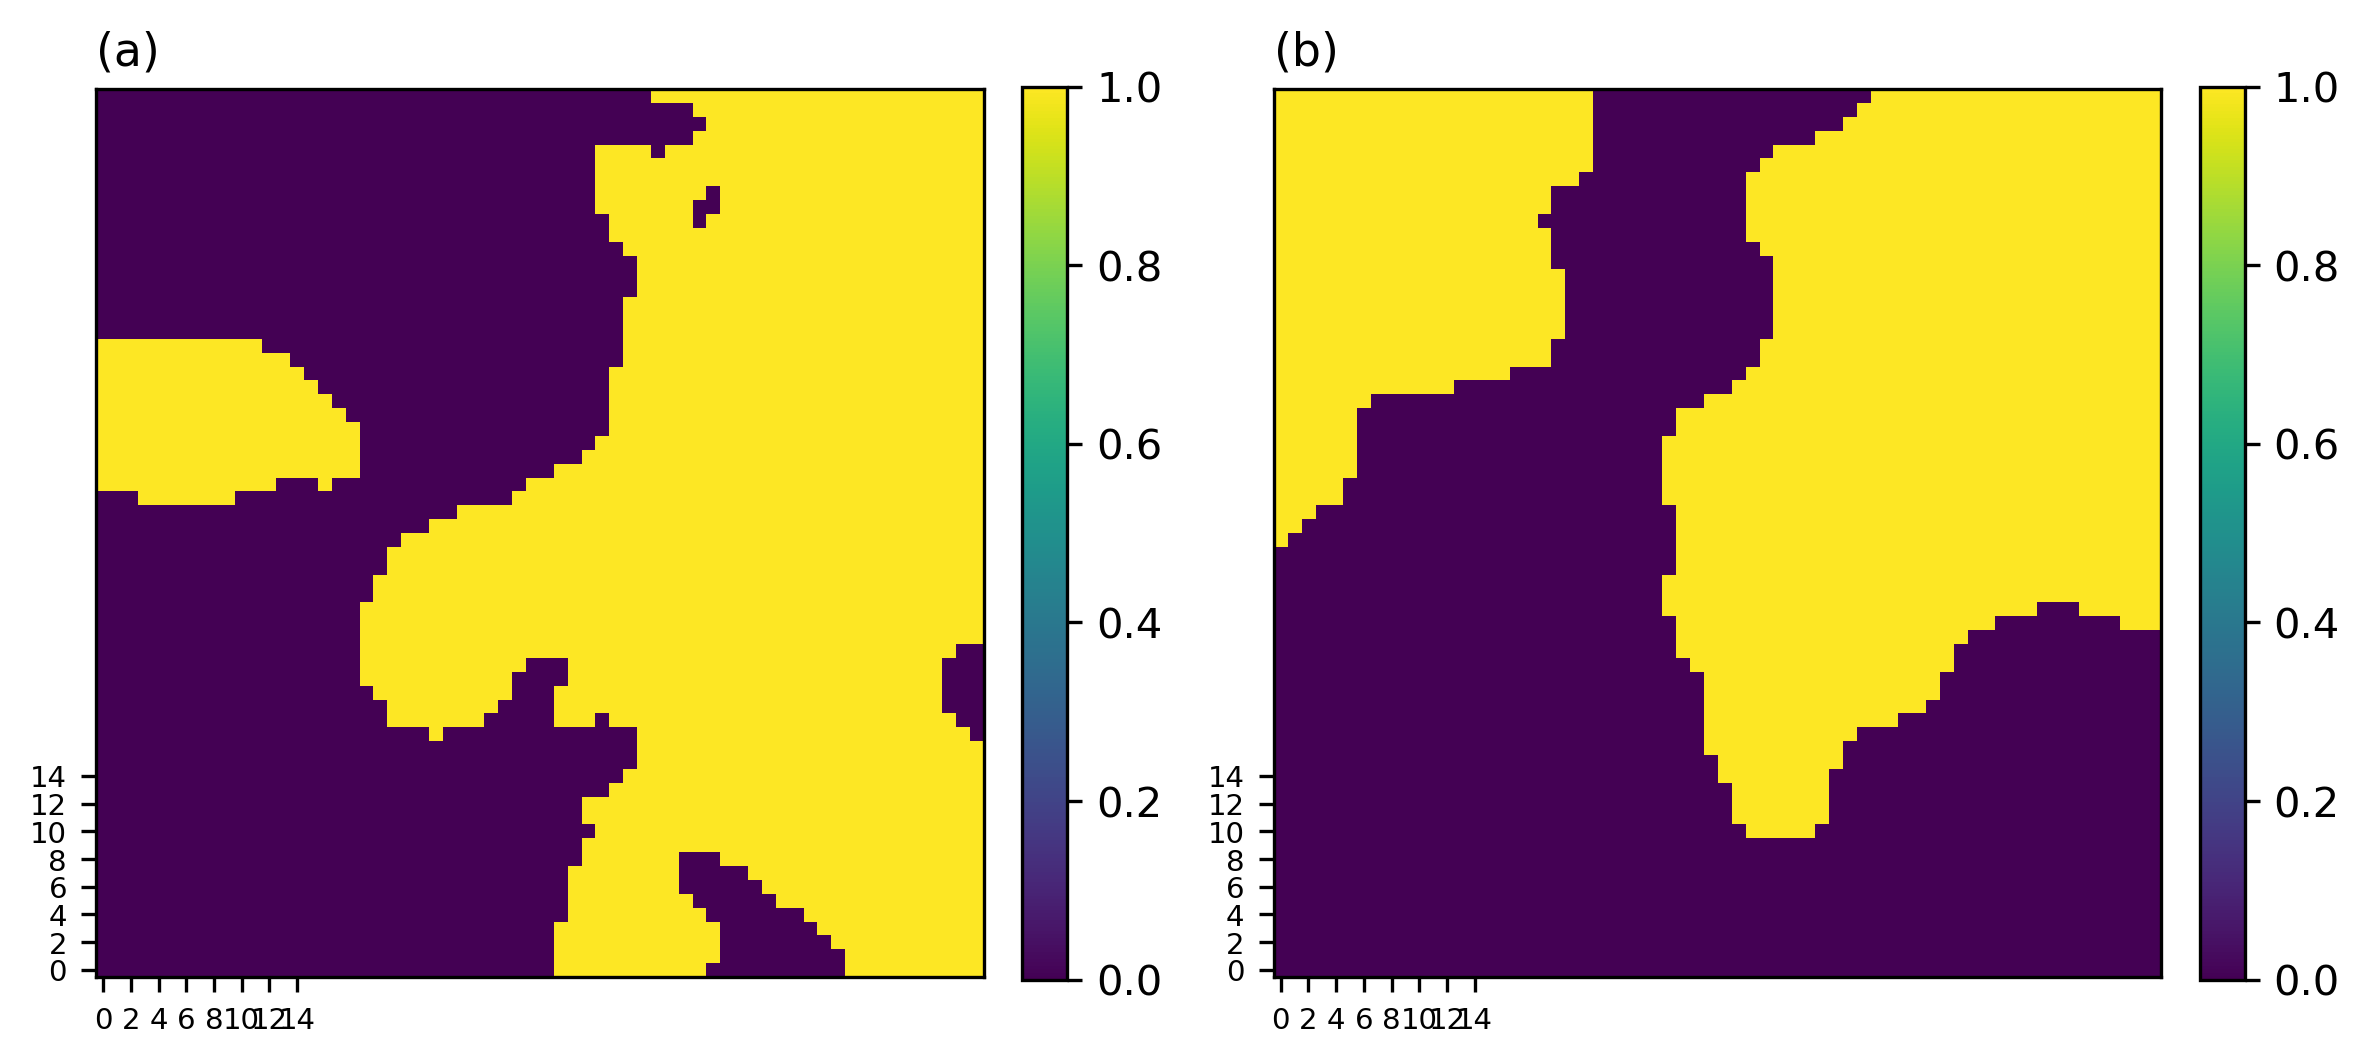

In [197]:
# visualise two examples of the field a(x)

tf1 = dataset.test_dbs[data_train_resolution].x[0, 0].unsqueeze(0).unsqueeze(0)
tf2 = dataset.test_dbs[data_test_resolutions[0]].x[1, 0].unsqueeze(0).unsqueeze(0)

fig, axs = plt.subplots(1, 2, figsize=(8, 4), dpi=300)

for ax, tf, label in zip(axs, [tf1, tf2], ['(a)', '(b)']):
    im = ax.imshow(tf[0, 0], cmap='viridis', interpolation='nearest', origin='lower')
    ax.set_title(label, fontsize=11, loc='left', pad=6)
    ax.set_xticks(range(0,16, 2))
    ax.set_yticks(range(0,16, 2))
    ax.tick_params(labelsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# fig.suptitle('Coefficient field $a(x)$', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('coefficient_fields.png', bbox_inches='tight', dpi=300)
plt.show()

In [198]:
# Instantiate Model
model = FNO(
    n_modes=FNO_n_modes,
    in_channels=FNO_in_channels,
    out_channels=FNO_out_channels,
    hidden_channels=FNO_hidden_channels,
    n_layers=FNO_n_layers,
    # projection_channel_ratio=FNO_projection_channel_ratio,
    factorization=FNO_factorization,
    # rank=FNO_rank,
)

# NOTE: FNO takes in inputs of shape (batch_size, in_channels, height, width) and outputs the same shape.
# If you want to pass a single observation, you need to add batch and channel dimensions, e.g., x[0, 0].unsqueeze(0).unsqueeze(0) to get shape (1, 1, 16, 16).

model = model.to(device)

n_params = count_model_params(model)
print(f"\nOur model has {n_params} parameters.")
sys.stdout.flush()


# Scheduler and Loss

optimizer = AdamW(model.parameters(), lr=8e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

l2loss = LpLoss(d=2, p=2)
h1loss = H1Loss(d=2)

train_loss = h1loss
eval_losses = {"h1": h1loss, "l2": l2loss}



Our model has 2698289 parameters.


In [199]:
# Train model
# Creating the trainer

trainer = Trainer(
    model=model,
    n_epochs=TRAIN_epochs,
    device=device,
    data_processor=data_processor,
    wandb_log=False,
    eval_interval=3,
    use_distributed=False,
    verbose=True,
)

# # We train and save checkpoints
# # Train from scratch
# trainer.train(
#     train_loader=train_loader,
#     test_loaders={},
#     optimizer=optimizer,
#     scheduler=scheduler,
#     regularizer=False,
#     training_loss=train_loss,
#     save_every=1,
#     save_dir="./checkpoints",
# )

torch.serialization.add_safe_globals([torch._C._nn.gelu])
torch.serialization.add_safe_globals([neuralop.layers.spectral_convolution.SpectralConv])

# Train from checkpoints
trainer.train(
    train_loader=train_loader,
    test_loaders={},
    optimizer=optimizer,
    scheduler=scheduler,
    regularizer=False,
    training_loss=train_loss,
    resume_from_dir="./checkpoints",
    save_dir="./checkpoints",
)

Trainer resuming from epoch 499
Training on 1000 samples
Testing on [] samples         on resolutions [].


{'train_err': 1.2546969037503004,
 'avg_loss': 0.04015030092000961,
 'avg_lasso_loss': None,
 'epoch_train_time': 1.4447610480056028}

In [256]:
# === MCMC HYPERPARAMETERS ===
MCMC_delta = 0.01  # can experiment later with adaptive delta, as in it gets smaller as the number of iterations increases.
MCMC_n_iterations = 100_000  # Most likely need it on the order of 100,000 to get good results, but we can test the code with fewer iterations first.
MCMC_tau = -1  # Smoothing parameter for the smooth threshold function. Higher values make it closer to a hard threshold, while lower values make it smoother. We can experiment with different values to see how it affects the results.


In [257]:
# MCMC helper functions

def log_likelihood(x: torch.Tensor, y: torch.Tensor, model, sigma=0.5275) -> torch.Tensor:
    """Inputs:
    - x: input tensor (location measurements of field θ)
    - y: observed output tensor (e.g., solution field u at locations x)
    - model: the trained FNO model that maps x to predicted y
    - sigma: standard deviation of the Gaussian likelihood
    Returns:
    - log-likelihood of observing y given x under the model's predictions"""
    # Ensure x and y are 4D tensors with shape (1, 1, height, width)
    # Ensure both x and y are on the same device as the model
    # x = x.to(device)
    # y = y.to(device)
    # Assuming Gaussian likelihood with fixed variance
    with torch.no_grad():
        forwards = model(x)
        mean = data_processor.out_normalizer.mean  # need to unnormalize the model outputs before comparing to y, since the model was trained on normalized data
        std = data_processor.out_normalizer.std
        forwards = forwards * std + mean
    forwards = forwards[0, 0]  # need .cpu() before .numpy()
    ll = -0.5 * torch.sum((y - forwards) ** 2).item() / sigma**2
    return ll


# Before the loop, build once:
_x_coords = np.linspace(0, 1, data_train_resolution)
_y_coords = np.linspace(0, 1, data_train_resolution)
_X, _Y = np.meshgrid(_x_coords, _y_coords)
_grid_points = np.column_stack([_X.ravel(), _Y.ravel()])
_gp = GaussianProcessRegressor(kernel=RBF(length_scale=0.3))

def sample_GP():
    sample = _gp.sample_y(_grid_points, n_samples=1, random_state=None)
    return sample.reshape(data_train_resolution, data_train_resolution)


# Before the loop
from sklearn.gaussian_process.kernels import Matern
# _kernel = RBF(length_scale=0.25)
_kernel = Matern(length_scale=0.3, nu=1) # nu=0.5 is even rougher
K_1d = _kernel(_x_coords.reshape(-1, 1))
K_1d += 1e-6 * np.eye(len(K_1d))
L_1d = np.linalg.cholesky(K_1d)


def sample_GP_kronecker():
    Z = np.random.randn(data_train_resolution, data_train_resolution)
    return L_1d @ Z @ L_1d.T


def T_push(x, tau=50, boundary=0):
    """A smooth approximation to the step function, which can be used to get a binary field from the GP sample while maintaining differentiability.
    
    See Akiyldiz for details.

    Combined with the option to get a hard threshold by setting tau=-1.
    """
    if tau == -1:
        return (x >= boundary).astype(float)

    return 0.5 * np.tanh(tau * x) + 0.5

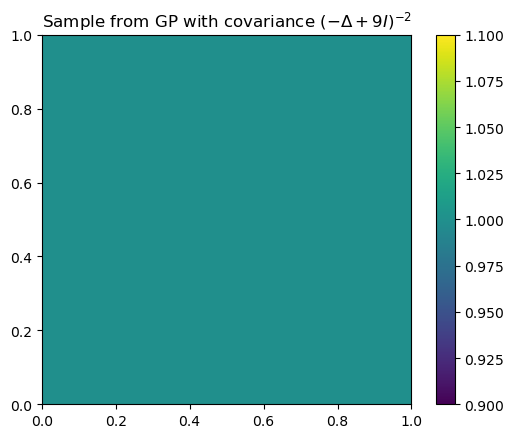

In [258]:
import numpy as np
import matplotlib.pyplot as plt

# grid size
N = 64
L = 1.0
h = L / N

def sample_GP_operator():
    # Fourier frequencies
    kx = 2 * np.pi * np.fft.fftfreq(N, d=h)
    ky = 2 * np.pi * np.fft.fftfreq(N, d=h)

    KX, KY = np.meshgrid(kx, ky, indexing='ij')

    # eigenvalues of (-Δ + 9I)
    A_eigs = KX**2 + KY**2 + 9.0

    # covariance eigenvalues = A^{-2}
    Cov_eigs = 1.0 / (A_eigs**2)

    # white noise in Fourier space
    z = np.random.randn(N, N) + 1j * np.random.randn(N, N)

    # scale by sqrt(covariance eigenvalues)
    u_hat = np.sqrt(Cov_eigs) * z

    # transform back
    u = np.fft.ifft2(u_hat).real
    return u

from scipy.ndimage import gaussian_filter

def sample_GP_operator_masked(u_current, bandwidth=0.1, smooth_sigma=2.0):
    """
    Sample a GP perturbation concentrated near the interface of u_current.
    
    bandwidth:    threshold on |u| to define the interface region.
                  In your domain u is real-valued after ifft2 — check
                  np.percentile(np.abs(u_current), 10) to calibrate this.
    smooth_sigma: Gaussian smoothing on the mask to avoid sharp cutoffs
                  creating spectral artifacts.
    """
    xi = sample_GP_operator()
    
    # Interface mask: near zero-crossings of u
    mask = (np.abs(u_current) < bandwidth).astype(float)
    mask = gaussian_filter(mask, sigma=smooth_sigma)
    
    # Renormalise so the masked sample has unit variance
    # (avoids the effective step size shrinking due to masking)
    if mask.max() > 1e-8:
        mask = mask / (mask.std() + 1e-8)
    
    return xi * mask


def sample_GP_operator_mixed(u_current, bandwidth=0.1, 
                               smooth_sigma=2.0, interface_weight=0.8):
    """
    Mixture proposal: interface-focused with probability interface_weight,
    global with probability (1 - interface_weight).
    
    The global component occasionally proposes large structural changes,
    preventing the chain from getting stuck in local topology.
    """
    if np.random.rand() < interface_weight:
        return sample_GP_operator_masked(u_current, bandwidth, smooth_sigma)
    else:
        return sample_GP_operator()


# visualize
plt.imshow(T_push(sample_GP_operator(), tau=-1), extent=[0,1,0,1], origin='lower')
plt.colorbar()
plt.title(r'Sample from GP with covariance $(-\Delta + 9I)^{-2}$')
plt.show()

<class 'numpy.ndarray'>


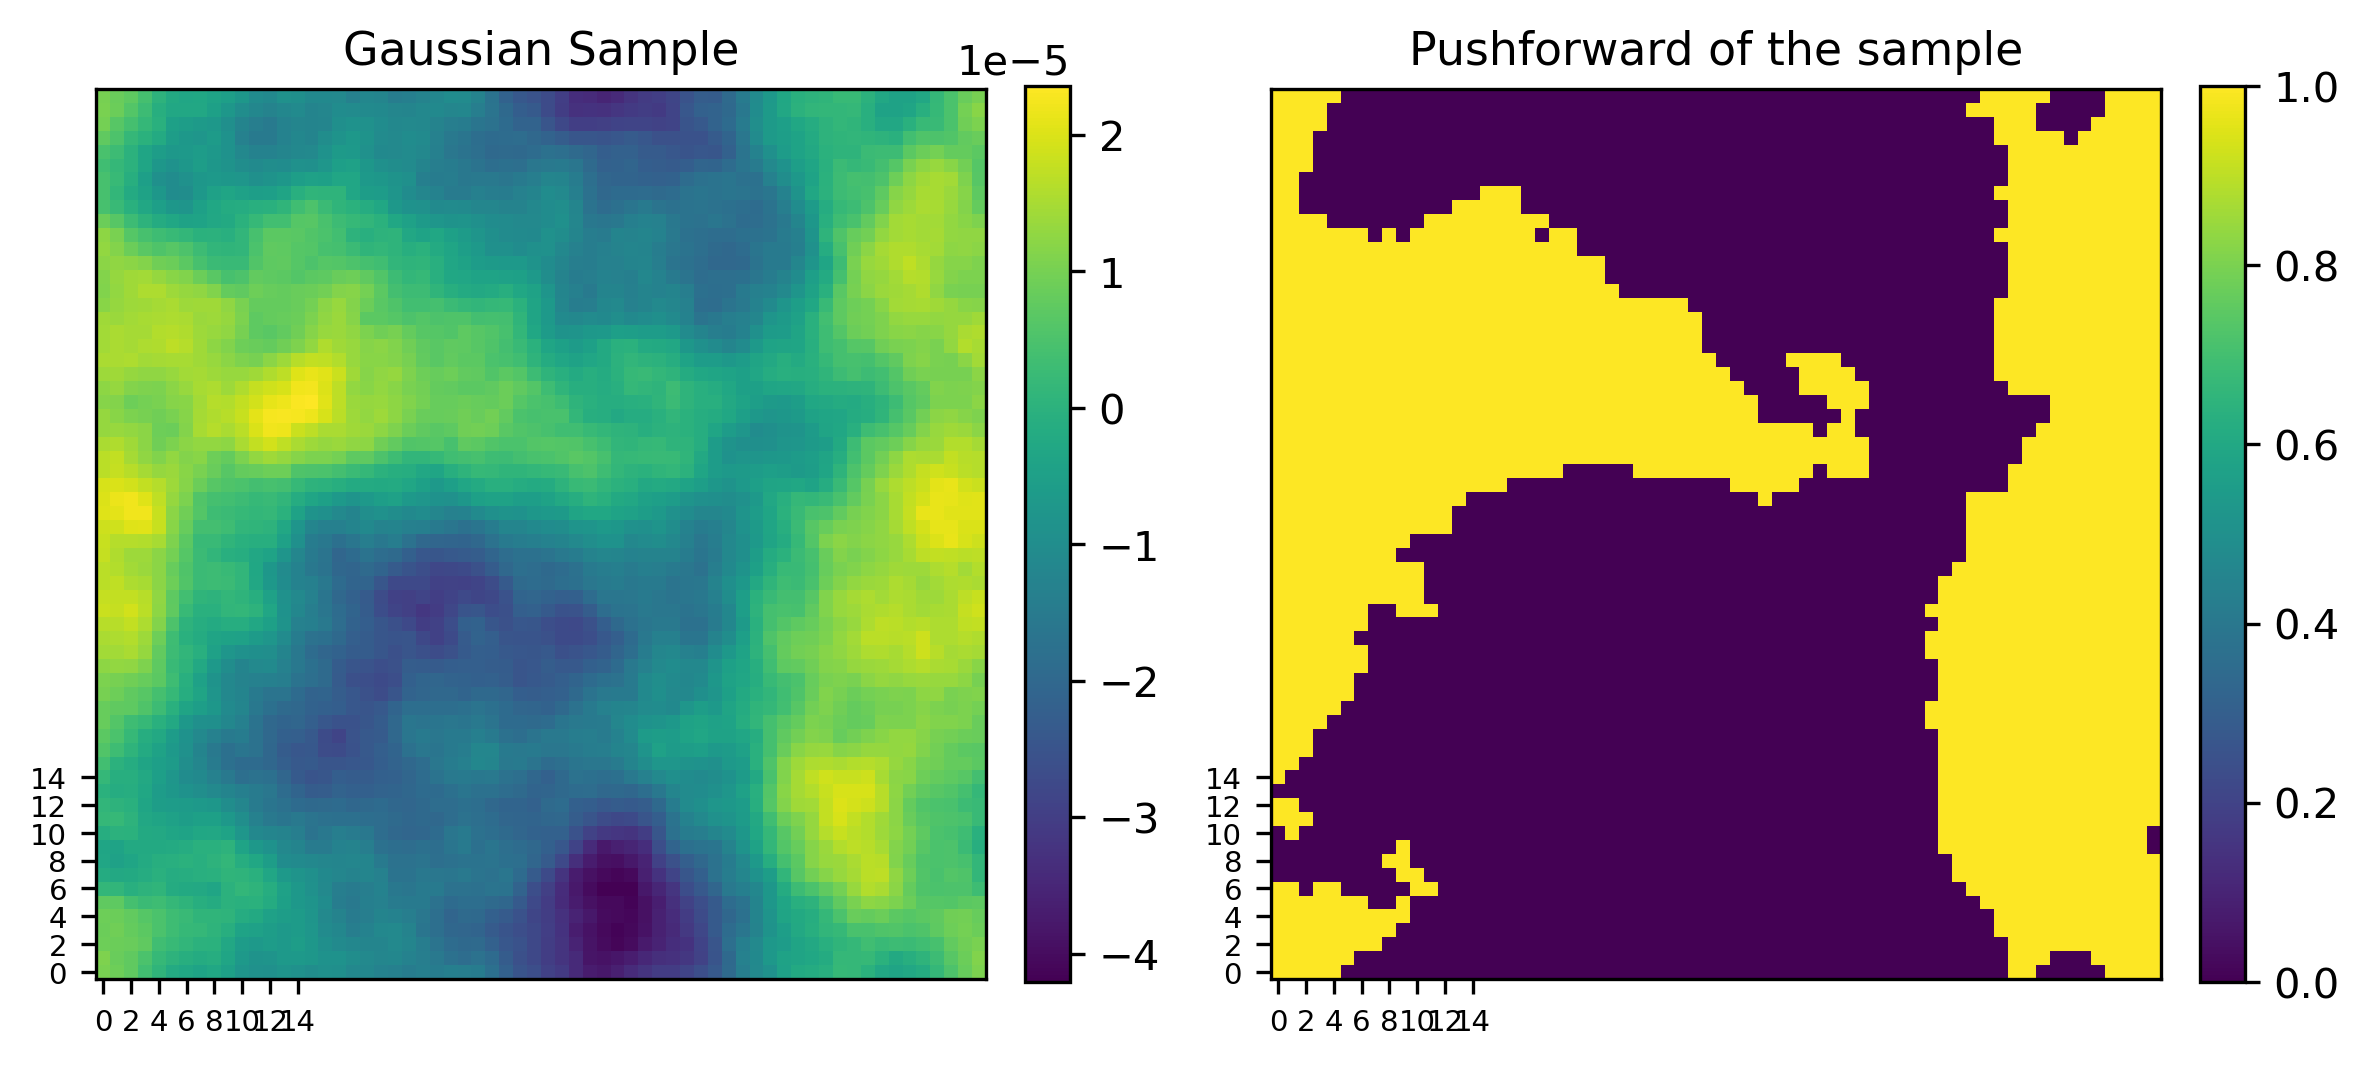

In [259]:
# visualise two examples of the field a(x)

tf1 = sample_GP_operator()
tf2 = T_push(tf1, tau=MCMC_tau)

print(type(tf1))
fig, axs = plt.subplots(1, 2, figsize=(8, 4), dpi=300)

for ax, tf, label in zip(axs, [tf1, tf2], ["Gaussian Sample", 'Pushforward of the sample']):
    im = ax.imshow(tf, cmap='viridis', interpolation='nearest', origin='lower')
    ax.set_title(label, fontsize=11, loc='center', pad=6)
    ax.set_xticks(range(0,16, 2))
    ax.set_yticks(range(0,16, 2))
    ax.tick_params(labelsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# fig.suptitle('Coefficient field $a(x)$', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('coefficient_fields.png', bbox_inches='tight', dpi=300)
plt.show()

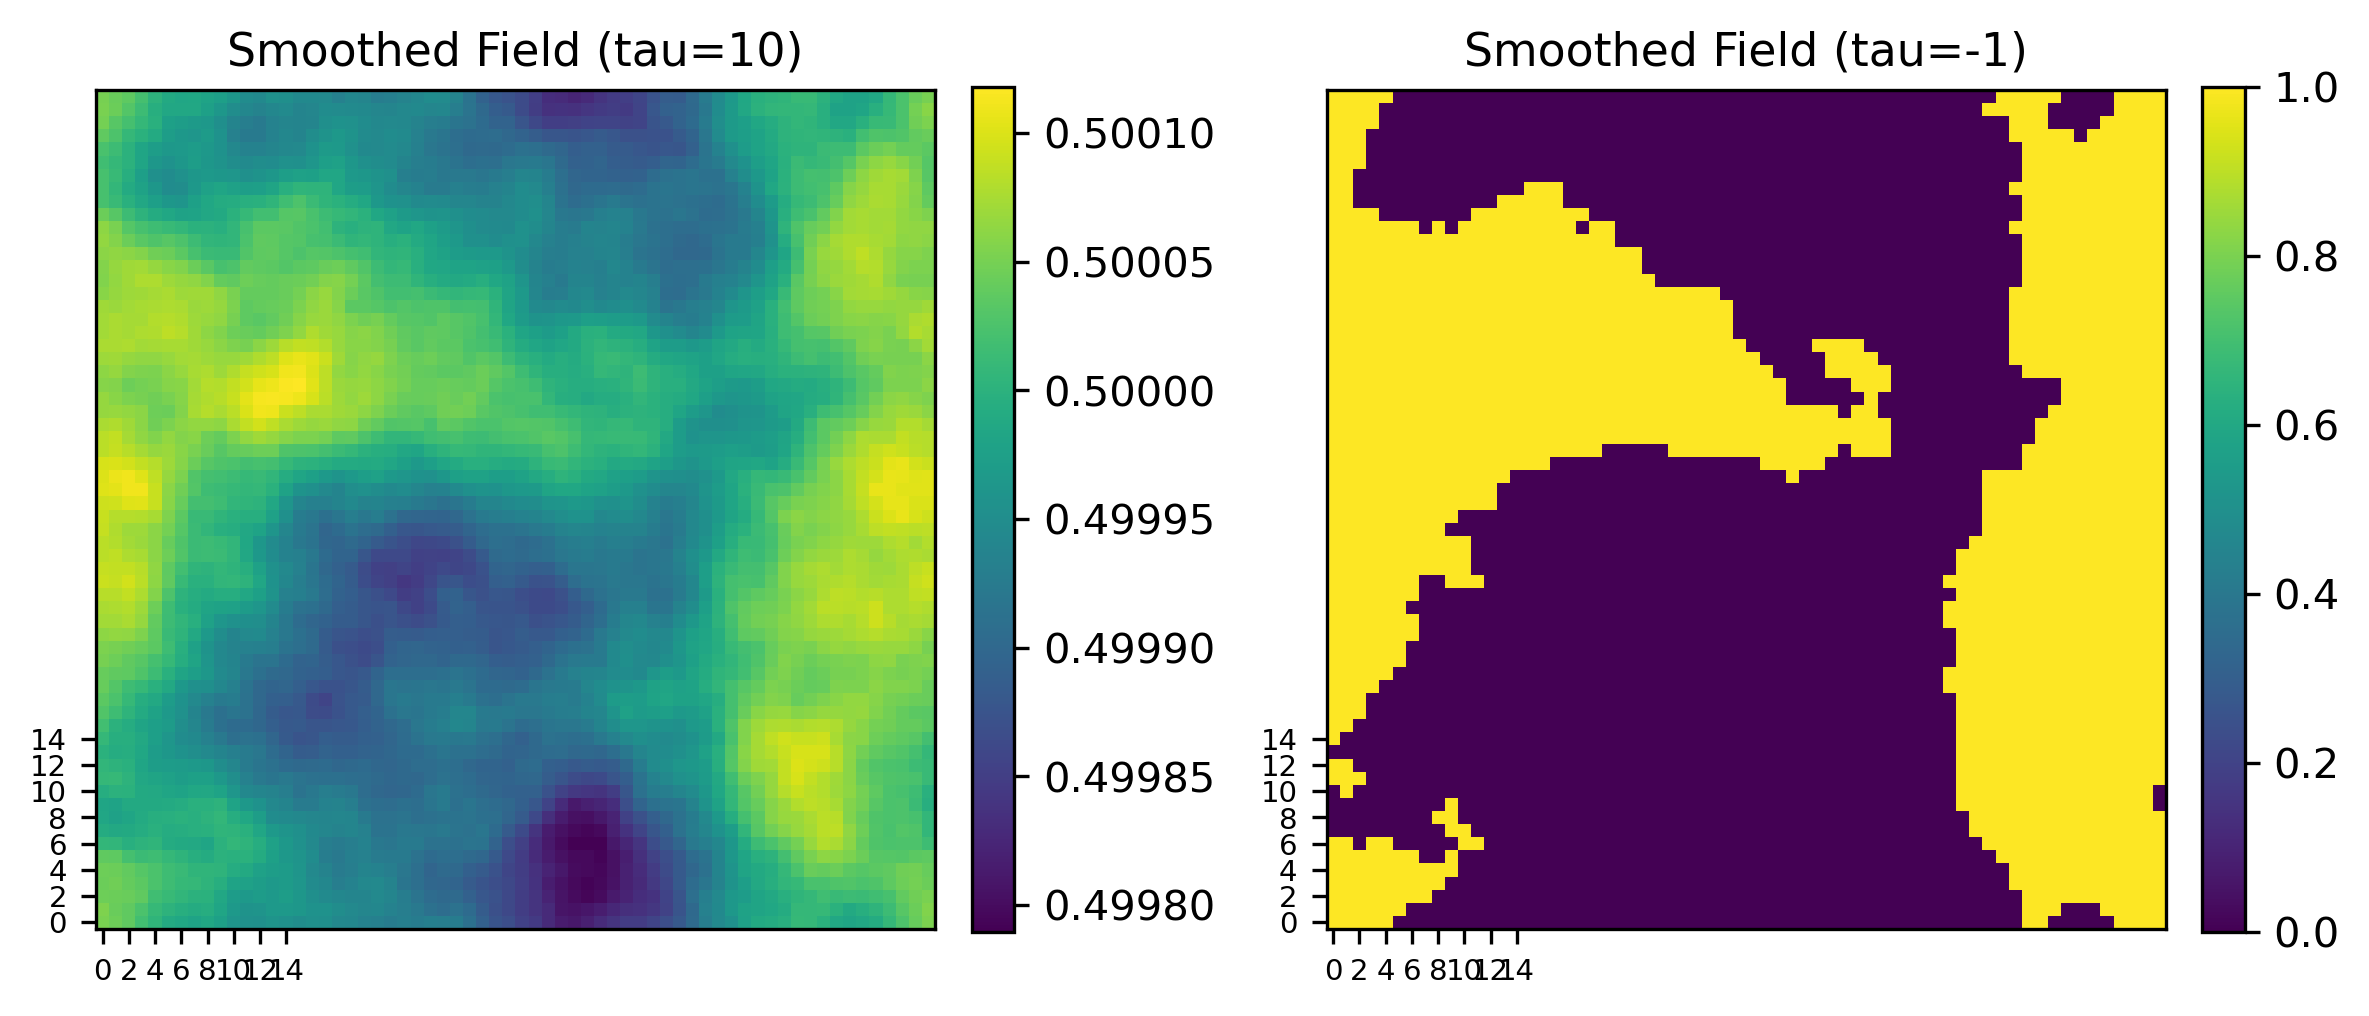

In [260]:
smooth1 = T_push(tf1, tau=10)
smooth2 = T_push(tf1, tau=-1)

fig, axs = plt.subplots(1, 2, figsize=(8, 4), dpi=300)

for ax, smooth, label in zip(axs, [smooth1, smooth2], ["Smoothed Field (tau=10)", "Smoothed Field (tau=-1)"]):
    im = ax.imshow(smooth, cmap='viridis', interpolation='nearest', origin='lower')
    ax.set_title(label, fontsize=11, loc='center', pad=6)
    ax.set_xticks(range(0,16, 2))
    ax.set_yticks(range(0,16, 2))
    ax.tick_params(labelsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# fig.suptitle('Coefficient field $a(x)$', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('tau_smooth_coefficient_fields.png', bbox_inches='tight', dpi=300)
plt.show()

In [261]:
# Get true field from test set
true_field = dataset.test_dbs[data_train_resolution].x[0, 0].unsqueeze(0).unsqueeze(0)  # shape (1, 1, train_resolution, train_resolution)
true_observations = dataset.test_dbs[data_train_resolution].y[0, 0].unsqueeze(0).unsqueeze(0)  # shape (1, 1, train_resolution, train_resolution)
sigma = true_observations.std().item()

# Instantiate MCMC
accepted = 0  # counter for accepted proposals
u_0 = sample_GP_operator()  # Initial proposal
theta_0 = T_push(u_0, tau=MCMC_tau)  # threshold to get binary field
theta_0_tensor = torch.tensor(theta_0, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
theta_evolution = [theta_0]  # to store the evolution of theta
loss_evolution = []
accepted = []

In [262]:
# Check these
print(true_observations.min(), true_observations.max(), true_observations.mean(), true_observations.std())

# And check what the model outputs raw
with torch.no_grad():
    raw_out = model(true_field.to(device))
print(raw_out.min(), raw_out.max(), raw_out.mean(), raw_out.std())

tensor(0.0002) tensor(0.9414) tensor(0.3594) tensor(0.2618)
tensor(-1.2021, device='cuda:0') tensor(1.6845, device='cuda:0') tensor(-0.0740, device='cuda:0') tensor(0.8039, device='cuda:0')


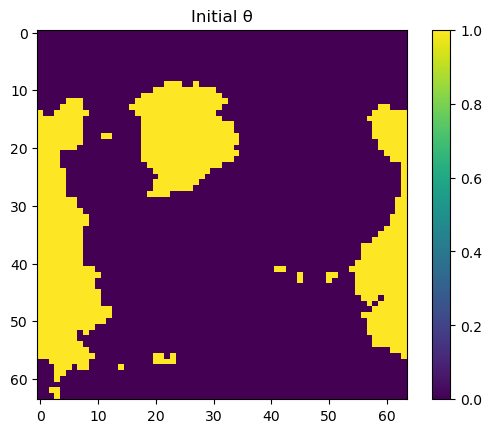

In [263]:
# Plot initial theta, to compare with how it evolves after MCMC loop
plt.imshow(theta_0, cmap='viridis', vmin=0, vmax=1)
plt.colorbar()
plt.title("Initial θ")
plt.show()

In [264]:
n_chains = 1
exploration_depth = 10
best_ll = -np.inf
best_theta = None
best_u = None  # track the latent GP variable
true_observations = true_observations.to(device)
for chain in range(n_chains):
    accepted = []
    u_0 = sample_GP_operator()
    theta_0 = T_push(u_0, tau=MCMC_tau)  # threshold to get binary field
    # Build tensor from the NEW theta_0, not the old one
    theta_0_tensor = torch.tensor(theta_0, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    ll_current = log_likelihood(theta_0_tensor, true_observations, model, sigma=sigma)
    for i in range(exploration_depth):
        # single MCMC step
        u_proposal = np.sqrt(1-2*MCMC_delta)*u_0 + np.sqrt(2*MCMC_delta)*sample_GP_operator()
        theta_proposal = T_push(u_proposal, tau=MCMC_tau)  # threshold to get binary field
        
        # Make proposals pytorch tensors, and add batch and channel dimensions to match FNO input shape (1, 1, n_sample, n_sample)
        theta_proposal_tensor = torch.tensor(theta_proposal, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
        # theta_0_tensor = torch.tensor(theta_0, dtype=torch.float32).unsqueeze(0).unsqueeze(0)


        # Inside the loop:
        ll_proposal = log_likelihood(theta_proposal_tensor, true_observations, model, sigma=sigma)
        acceptance_prob = min(1, np.exp(ll_proposal - ll_current))

        if np.random.rand() < acceptance_prob:
            theta_0 = theta_proposal
            u_0 = u_proposal
            theta_0_tensor = theta_proposal_tensor
            ll_current = ll_proposal  # reuse, don't recompute
            accepted += [1]
            theta_evolution.append(theta_0)
        else:
            accepted += [0]
        if (i+1) % 500 == 0:
            print(f"Iteration {i+1}/{exploration_depth}, Acceptance Rate: {sum(accepted[-1000:])/1000:.3f}")
    if ll_current > best_ll:
        best_ll = ll_current
        best_theta = theta_0
        best_u = u_0  # save the latent, not just the threshold

# Then run long chain from best starting point
print(best_theta)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


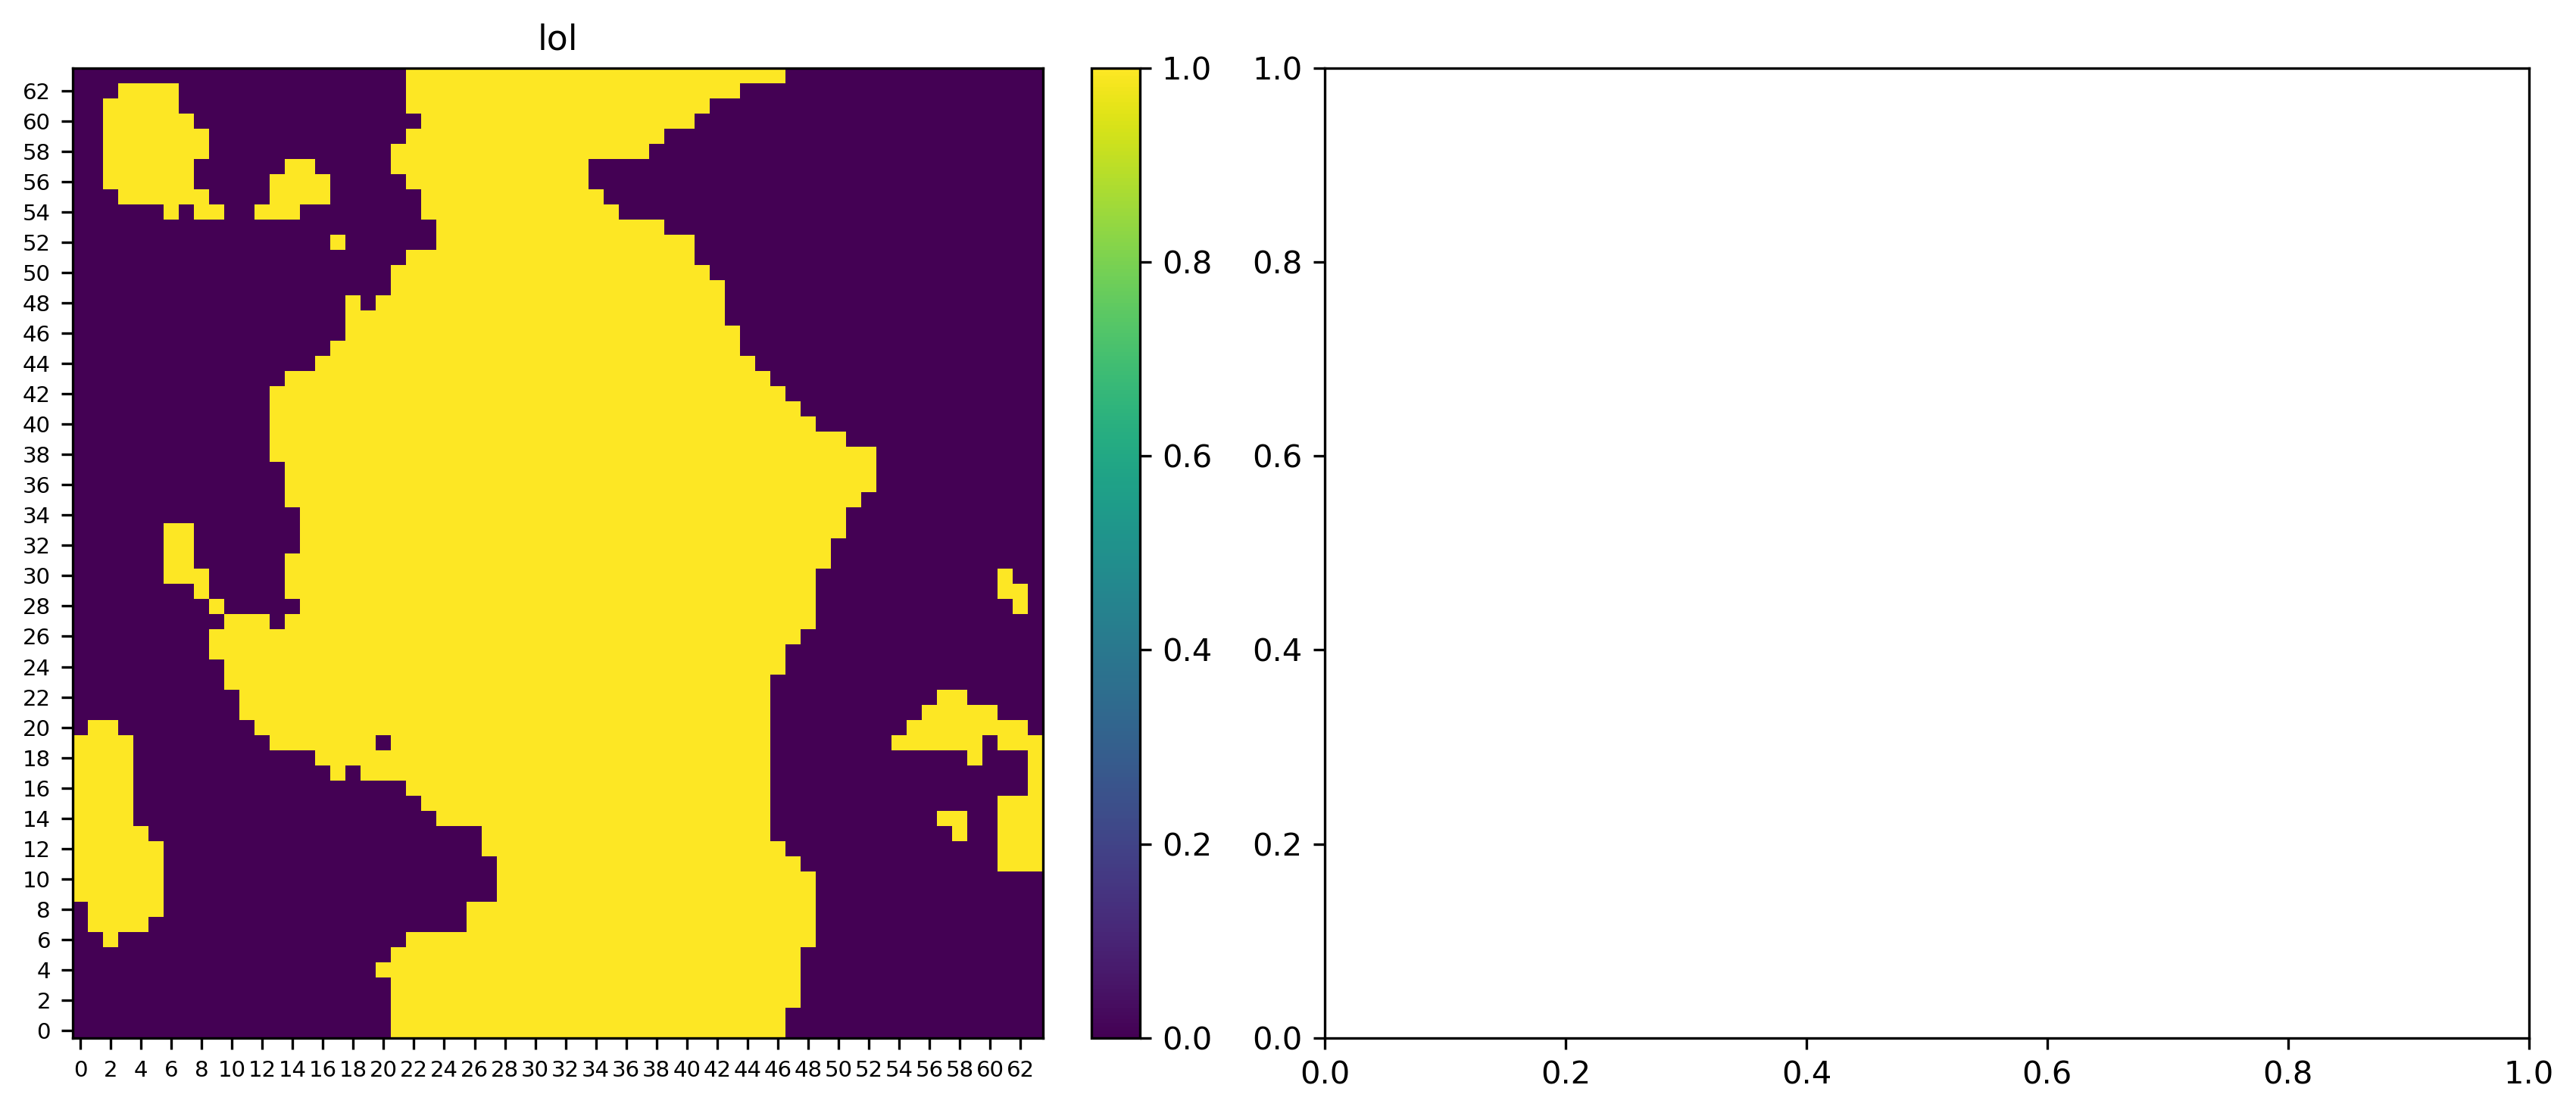

In [265]:
fig1, axs1 = plt.subplots(1, 2, figsize=(12, 5), dpi=300)
im = axs1[0].imshow(best_theta, cmap='viridis', interpolation='nearest', origin='lower')
axs1[0].set_title("lol", fontsize=11, loc='center', pad=6)
axs1[0].set_xticks(range(0, best_theta.shape[0], 2))
axs1[0].set_yticks(range(0, best_theta.shape[1], 2))
axs1[0].tick_params(labelsize=7)
plt.colorbar(im, ax=axs1[0], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [266]:
# # Run MCMC
# # import time
# # for i in range(MCMC_n_iterations):
# #     t0 = time.perf_counter()
# #     u_proposal = np.sqrt(1-2*MCMC_delta)*u_0 + np.sqrt(2*MCMC_delta)*sample_GP_kronecker()
# #     t1 = time.perf_counter()
# #     theta_proposal = smooth_threshold(u_proposal)
# #     theta_proposal_tensor = torch.tensor(theta_proposal, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
# #     t2 = time.perf_counter()
# #     ll_proposal = log_likelihood(theta_proposal_tensor, true_observations, model, sigma=sigma)
# #     t3 = time.perf_counter()

# #     print(f"GP sample: {t1-t0:.3f}s | tensor prep: {t2-t1:.3f}s | likelihood: {t3-t2:.3f}s")
# #     break  # just time one iteration first
# true_observations = true_observations.to(device)
# u_0 = best_u  # latent GP variable — correct starting point for pCN
# theta_0 = best_theta
# theta_0_tensor = torch.tensor(theta_0, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
# ll_current = log_likelihood(theta_0_tensor, true_observations, model, sigma=sigma)
# for i in range(MCMC_n_iterations):
#     # single MCMC step
#     u_proposal = np.sqrt(1-2*MCMC_delta)*u_0 + np.sqrt(2*MCMC_delta)*sample_GP_kronecker()
#     theta_proposal = T_push(u_proposal, tau=MCMC_tau)  # threshold to get binary field
    
#     # Make proposals pytorch tensors, and add batch and channel dimensions to match FNO input shape (1, 1, n_sample, n_sample)
#     theta_proposal_tensor = torch.tensor(theta_proposal, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
#     # theta_0_tensor = torch.tensor(theta_0, dtype=torch.float32).unsqueeze(0).unsqueeze(0)


#     # Inside the loop:
#     ll_proposal = log_likelihood(theta_proposal_tensor, true_observations, model, sigma=sigma)
#     acceptance_prob = min(1, np.exp(ll_proposal - ll_current))

#     if np.random.rand() < acceptance_prob:
#         theta_0 = theta_proposal
#         u_0 = u_proposal
#         theta_0_tensor = theta_proposal_tensor
#         ll_current = ll_proposal  # reuse, don't recompute
#         accepted += [1]
#         theta_evolution.append(theta_0)
#     else:
#         accepted += [0]
#     theta_evolution.append(theta_0)
#     loss_evolution.append(ll_current)
#     if (i+1) % 1000 == 0:
#         print(f"Iteration {i+1}/{MCMC_n_iterations}, Acceptance Rate: {sum(accepted[-1000:])/1000:.3f}")


In [267]:
u_sample = sample_GP_operator()
print(np.percentile(np.abs(u_sample), [10, 25, 50]))
# Set bandwidth to roughly the 10th-25th percentile value

[1.59150788e-06 3.98724727e-06 8.76258280e-06]


In [268]:
from collections import deque
import numpy as np
import torch

# --- Hyperparameters ---
target_acceptance = 0.234
adapt_interval    = 1000        # match your existing print interval
delta_min, delta_max = 1e-6, 0.49   # keep sqrt(1-2δ) real, so δ < 0.5

nll_window = deque(maxlen=200)
n_accepted_window = 0           # resets every adapt_interval


true_observations = true_observations.to(device)
u_0 = best_u  # latent GP variable — correct starting point for pCN
theta_0 = best_theta
theta_0_tensor = torch.tensor(theta_0, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
ll_current = log_likelihood(theta_0_tensor, true_observations, model, sigma=sigma)
for i in range(MCMC_n_iterations):

    # --- Proposal (your original formula, unchanged) ---
    u_proposal     = np.sqrt(1 - 2 * MCMC_delta) * u_0 + np.sqrt(2 * MCMC_delta) * sample_GP_operator_mixed(u_0, bandwidth=1.5e-5, smooth_sigma=2.0, interface_weight=0.8)
    theta_proposal = T_push(u_proposal, tau=MCMC_tau)
    theta_proposal_tensor = torch.tensor(theta_proposal, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    # --- Accept / reject ---
    ll_proposal      = log_likelihood(theta_proposal_tensor, true_observations, model, sigma=sigma)
    acceptance_prob  = min(1, np.exp(ll_proposal - ll_current))

    if np.random.rand() < acceptance_prob:
        theta_0        = theta_proposal
        u_0            = u_proposal
        theta_0_tensor = theta_proposal_tensor
        ll_current     = ll_proposal
        accepted          += [1]
        n_accepted_window += 1
    else:
        accepted += [0]

    theta_evolution.append(theta_0)
    loss_evolution.append(ll_current)
    nll_window.append(-ll_current)      # store NLL (positive)

    # --- Adapt delta every adapt_interval steps ---
    if (i + 1) % adapt_interval == 0:
        acceptance_rate   = n_accepted_window / adapt_interval
        n_accepted_window = 0            # reset for next window

        # Exponential scaling: nudge delta toward target acceptance
        factor     = np.exp(acceptance_rate - target_acceptance)
        MCMC_delta = float(np.clip(MCMC_delta * factor, delta_min, delta_max))

        avg_nll = np.mean(nll_window)

        print(f"Iteration {i+1}/{MCMC_n_iterations} | "
              f"accept={acceptance_rate:.3f} | "
              f"delta={MCMC_delta:.5f} | "
              f"avg NLL (last 200)={avg_nll:.3f}")

Iteration 1000/100000 | accept=0.051 | delta=0.00833 | avg NLL (last 200)=139.045
Iteration 2000/100000 | accept=0.022 | delta=0.00674 | avg NLL (last 200)=72.195
Iteration 3000/100000 | accept=0.032 | delta=0.00550 | avg NLL (last 200)=41.968
Iteration 4000/100000 | accept=0.031 | delta=0.00449 | avg NLL (last 200)=34.134
Iteration 5000/100000 | accept=0.033 | delta=0.00368 | avg NLL (last 200)=30.807
Iteration 6000/100000 | accept=0.041 | delta=0.00303 | avg NLL (last 200)=30.084
Iteration 7000/100000 | accept=0.095 | delta=0.00264 | avg NLL (last 200)=26.116
Iteration 8000/100000 | accept=0.093 | delta=0.00229 | avg NLL (last 200)=26.736
Iteration 9000/100000 | accept=0.103 | delta=0.00201 | avg NLL (last 200)=25.402
Iteration 10000/100000 | accept=0.122 | delta=0.00180 | avg NLL (last 200)=22.802
Iteration 11000/100000 | accept=0.211 | delta=0.00176 | avg NLL (last 200)=21.181
Iteration 12000/100000 | accept=0.248 | delta=0.00178 | avg NLL (last 200)=20.653
Iteration 13000/100000 |

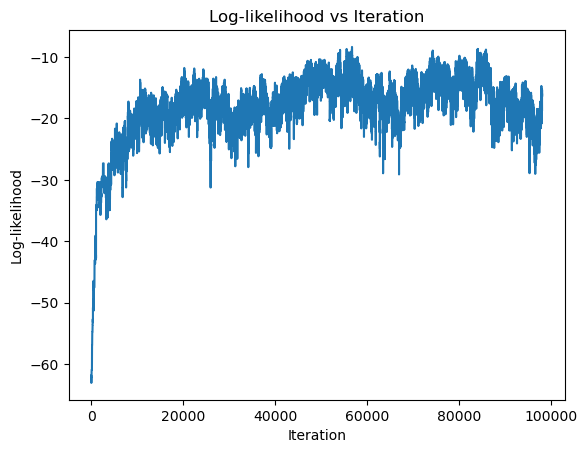

In [269]:
# Plot loss, compare predicted vs true_FNO vs absolute true
plt.plot(loss_evolution[2000:])
plt.title("Log-likelihood vs Iteration")
plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")
plt.show()

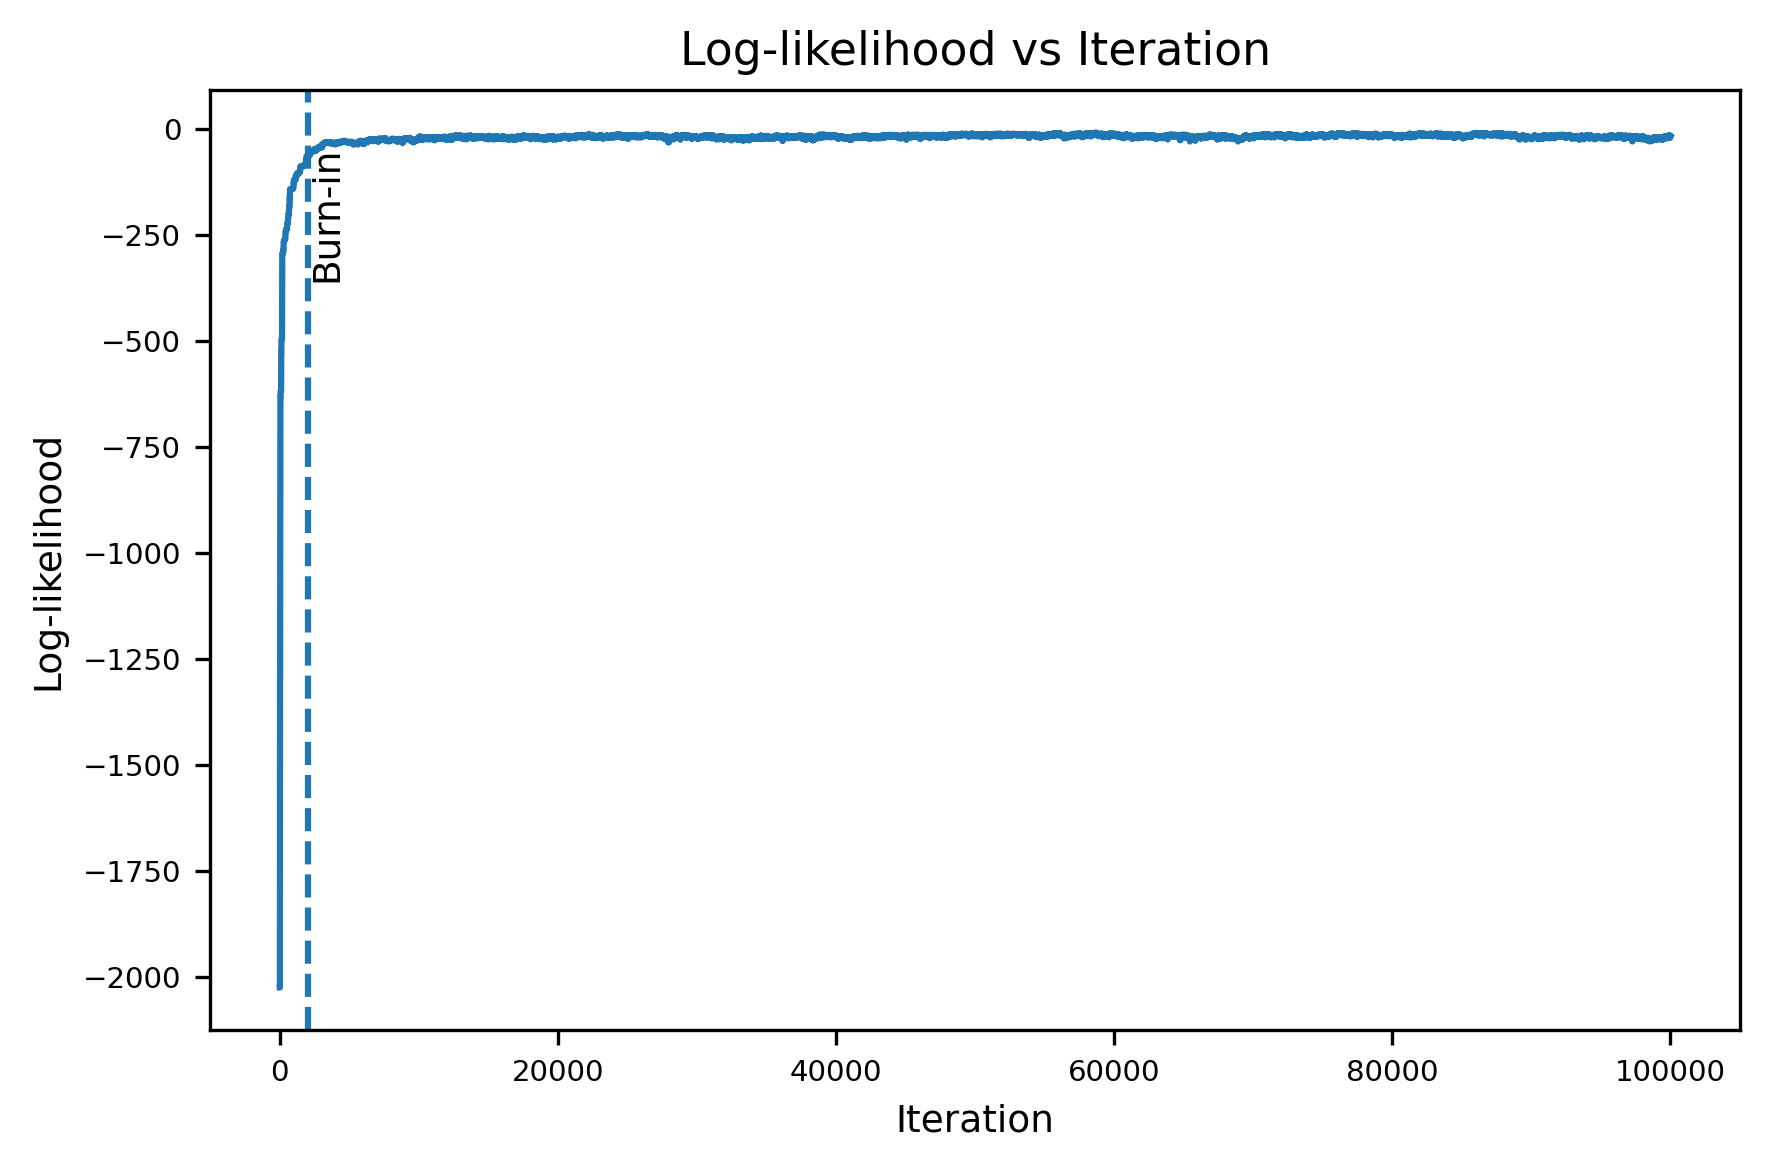

In [270]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=300)

burn_in = 2000

ax.plot(loss_evolution)
ax.axvline(burn_in, linestyle='--')

ax.text(
    burn_in + 100,                     # shift slightly right
    max(loss_evolution) * 5,         # near top
    "Burn-in",
    fontsize=9,
    rotation=90,
    va='top'
)

ax.set_title("Log-likelihood vs Iteration", fontsize=11, loc='center', pad=6)
ax.set_xlabel("Iteration", fontsize=9)
ax.set_ylabel("Log-likelihood", fontsize=9)


ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('loss_curve.png', bbox_inches='tight', dpi=300)
plt.show()

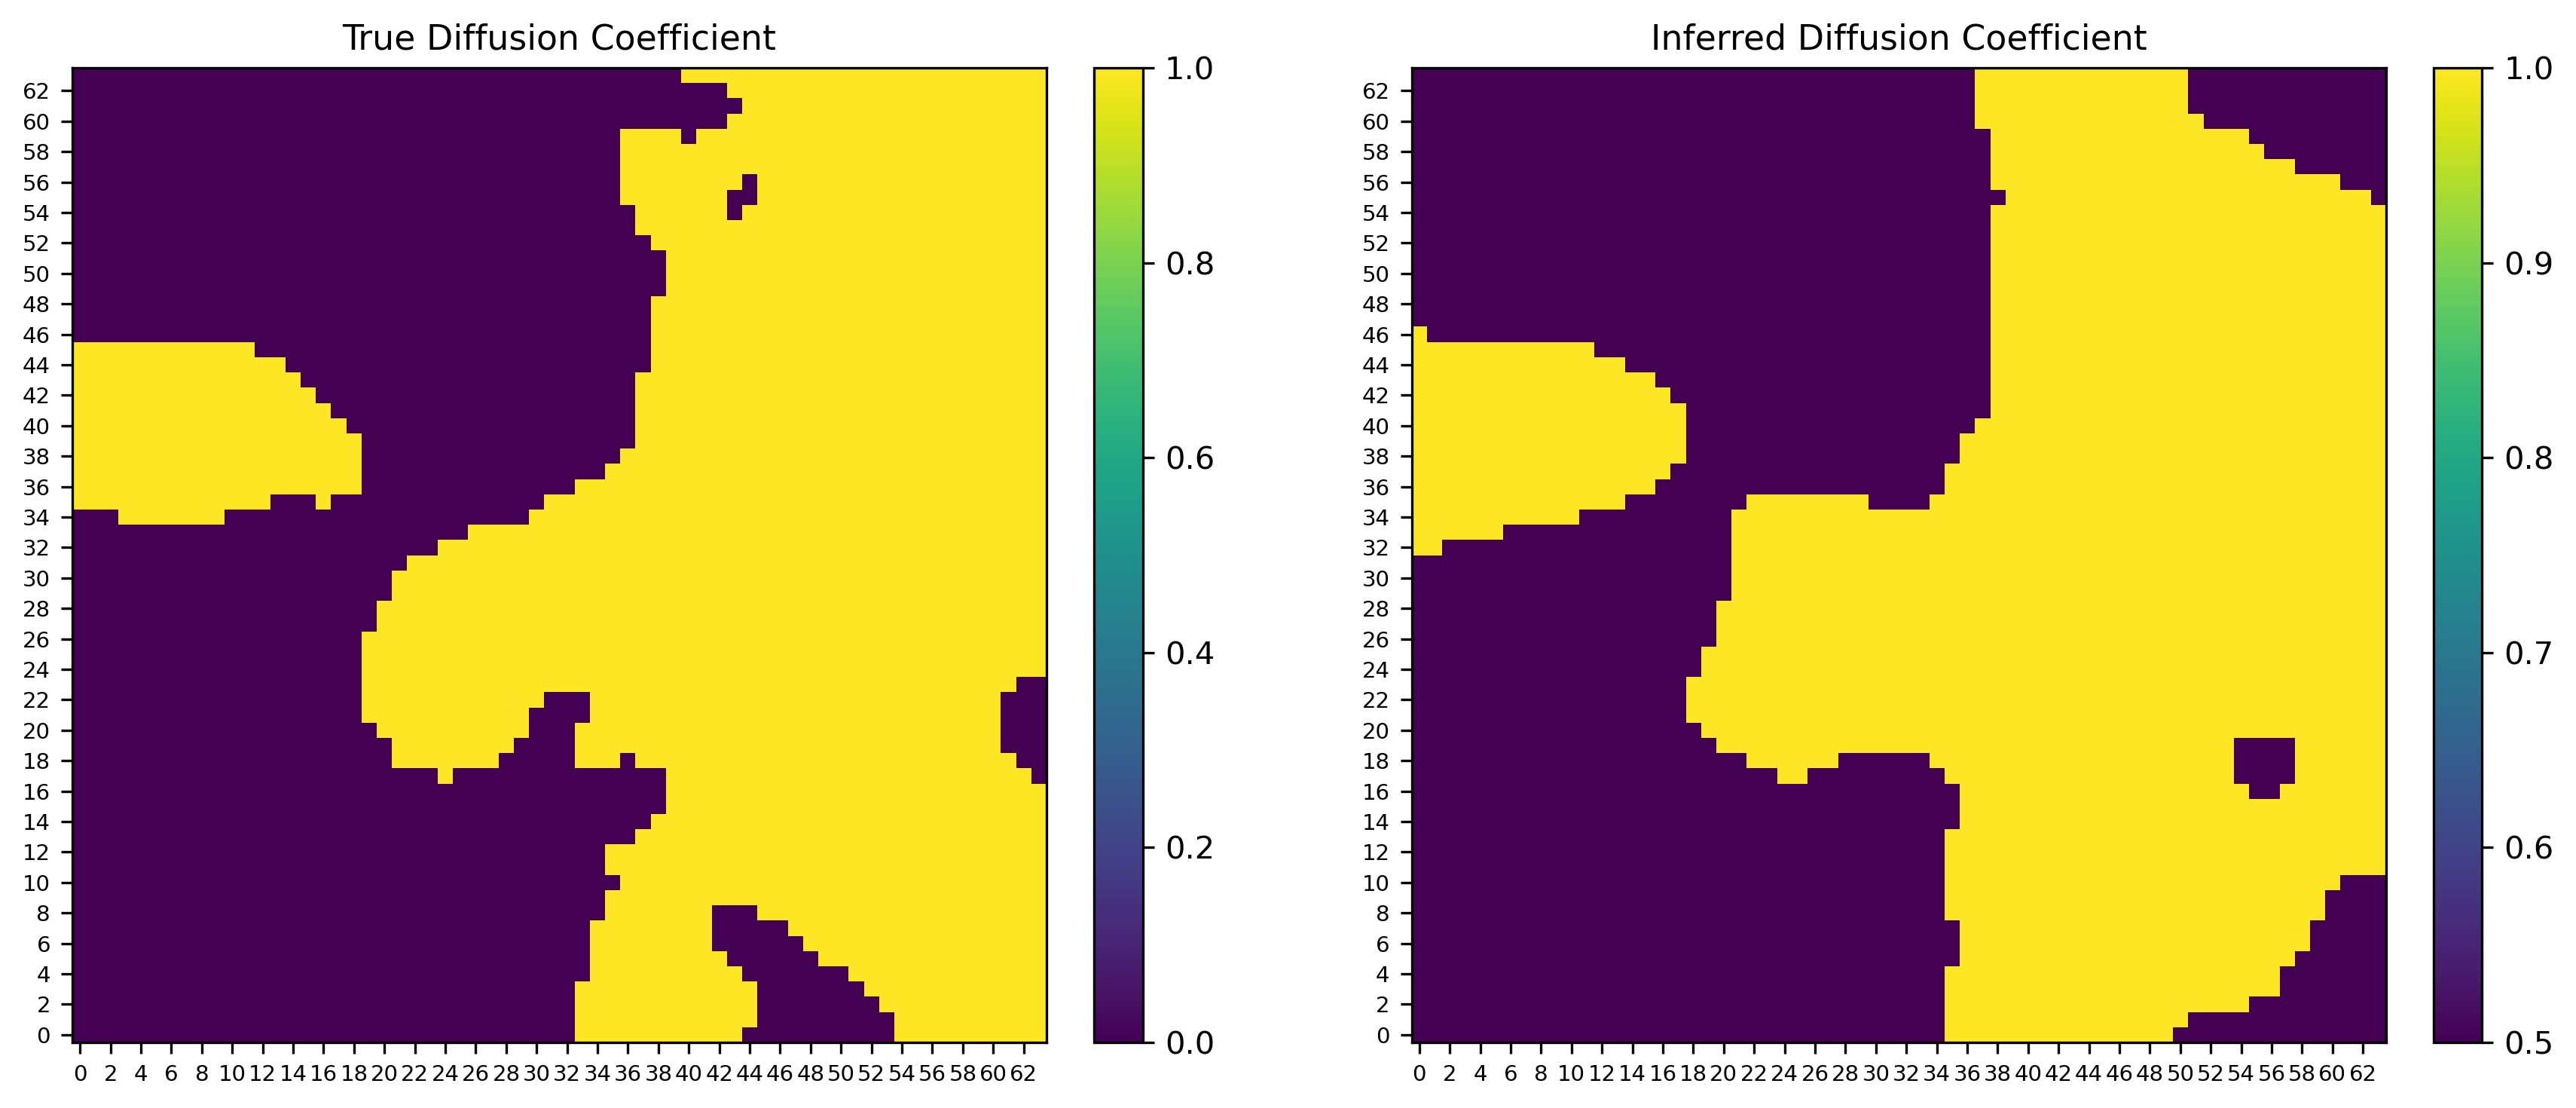

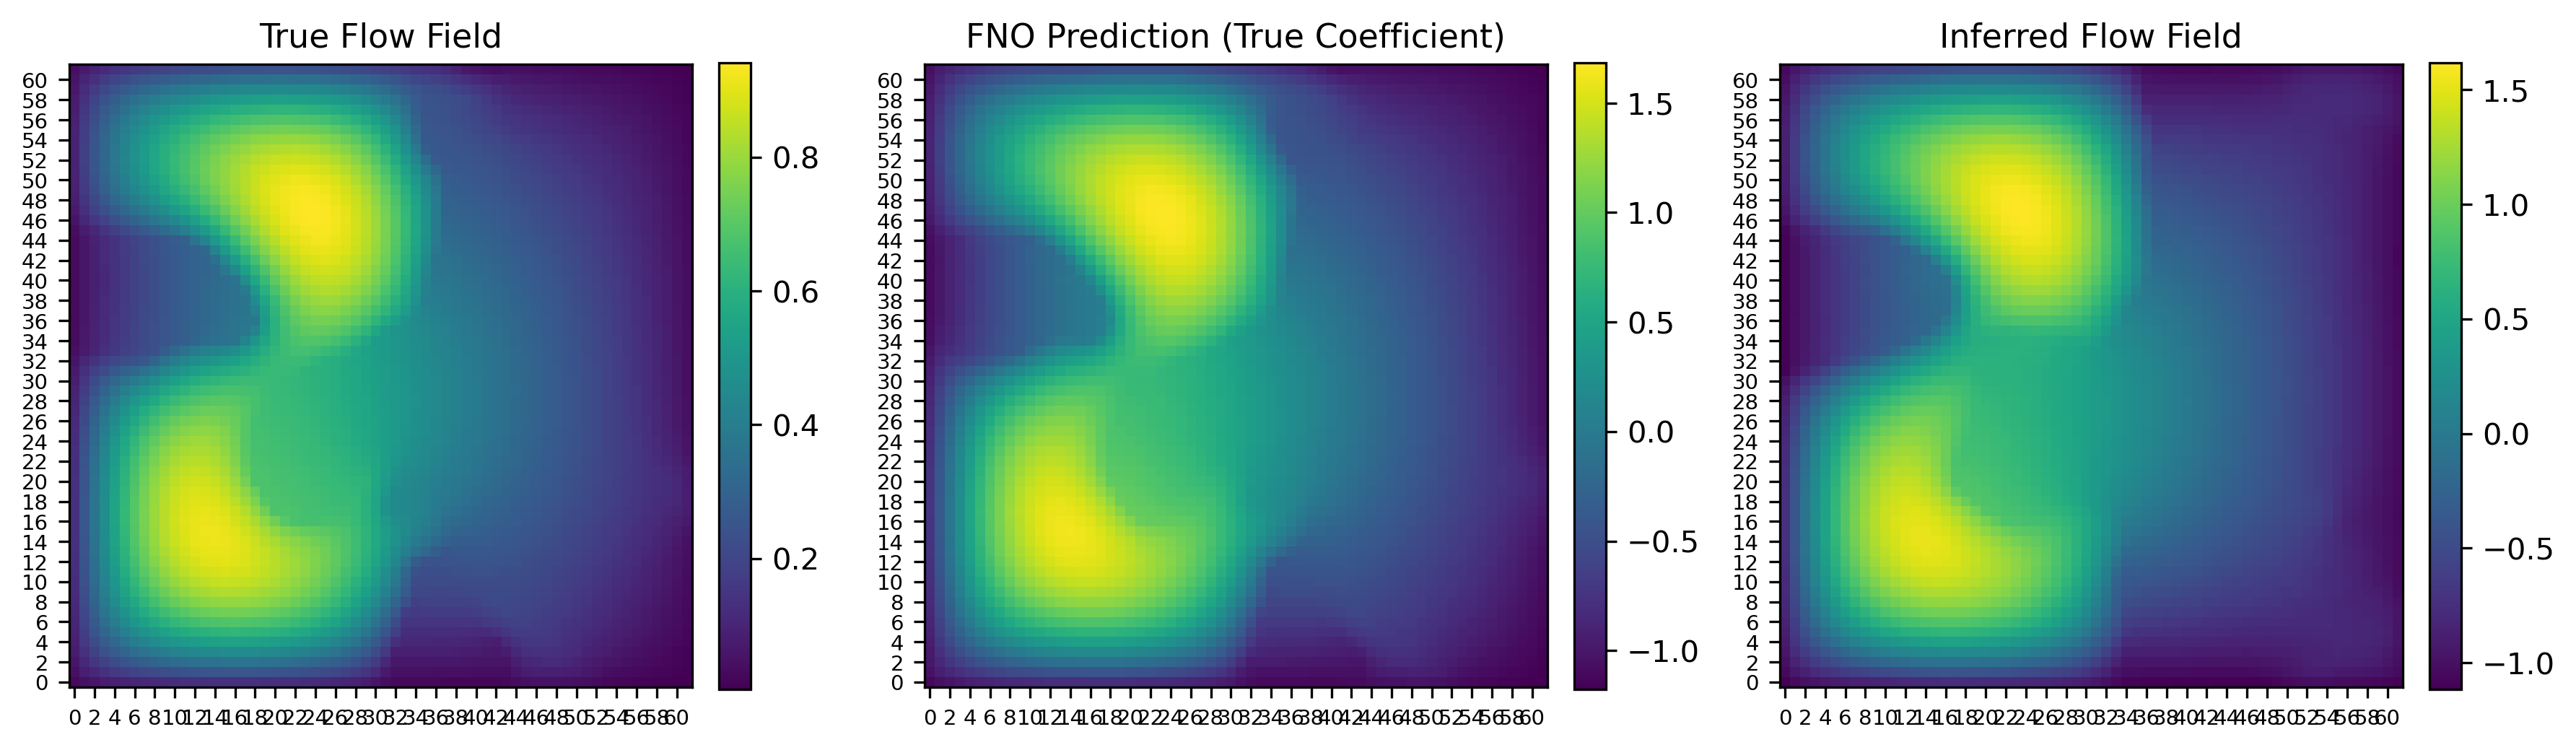

In [271]:
with torch.no_grad():
    forwards = model(true_field[0,0].unsqueeze(0).unsqueeze(0).to(device))

# Compute predicted solution
with torch.no_grad():
    predicted_solution = model(theta_0_tensor.to(device)).cpu().numpy()[0, 0]

# FNO forward pass on true field
fno_prediction = forwards.cpu().numpy()[0, 0]

# ----------------------
# First figure (top row)
# ----------------------
fig1, axs1 = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

fields1 = [
    true_field.cpu().numpy()[0, 0],
    T_push(theta_0, boundary=0.5),
    fno_prediction,
]

titles1 = [
    "True Diffusion Coefficient",
    "Inferred Diffusion Coefficient",
]

for ax, field, title in zip(axs1, fields1, titles1):
    im = ax.imshow(field, cmap='viridis', interpolation='nearest', origin='lower')
    ax.set_title(title, fontsize=11, loc='center', pad=6)
    ax.set_xticks(range(0, field.shape[0], 2))
    ax.set_yticks(range(0, field.shape[1], 2))
    ax.tick_params(labelsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('true_vs_inferred_coefficients.png', bbox_inches='tight', dpi=300)


# ----------------------
# Second figure (bottom row)
# ----------------------
fig2, axs2 = plt.subplots(1, 3, figsize=(12, 4), dpi=300)

fields2 = [
    true_observations.cpu().numpy()[0, 0],
    fno_prediction,
    predicted_solution,
    
]

titles2 = [
    "True Flow Field",
    "FNO Prediction (True Coefficient)",
    "Inferred Flow Field"
]

for ax, field, title in zip(axs2, fields2, titles2):
    im = ax.imshow(field[1:field.shape[0]-1, 1:field.shape[1]-1], cmap='viridis', interpolation='nearest', origin='lower')
    ax.set_title(title, fontsize=11, loc='center', pad=6)
    ax.set_xticks(range(0, field.shape[0]-2, 2))
    ax.set_yticks(range(0, field.shape[1]-2, 2))
    ax.tick_params(labelsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('true_vs_inferred_flows.png', bbox_inches='tight', dpi=300)

plt.show()

In [272]:
# FNO error on the true coefficient -- this is your best possible NLL
theta_true_tensor = torch.tensor(true_field.cpu().numpy()[0, 0], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
ll_true = log_likelihood(theta_true_tensor, true_observations, model, sigma=sigma)
print(f"NLL with true coefficient: {ll_true:.2f}")
print(f"NLL of MCMC solution:      {ll_current:.2f}")

NLL with true coefficient: -6.89
NLL of MCMC solution:      -16.13


In [273]:
# Estimate a reasonable sigma from the FNO's own error on the true field
with torch.no_grad():
    fno_pred = model(theta_true_tensor)
    # unnormalise...
    residuals = (true_observations - fno_pred[0,0])
    print(f"Suggested sigma: {residuals.std().item():.4f}")

Suggested sigma: 0.5424


Text(0.5, 1.0, 'Mean absolute change per step')

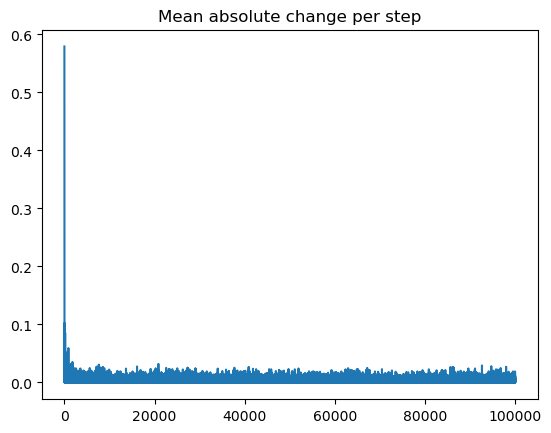

In [274]:
# Plot how much the chain moves each step
diffs = [np.mean(np.abs(theta_evolution[i] - theta_evolution[i-1])) 
         for i in range(1, len(theta_evolution))]
plt.plot(diffs)
plt.title("Mean absolute change per step")